# LTCM: Delta and Vega Hedging of Long-Dated Options

## Project Objective: 
This project reconstructs the performance of a stylized LTCM strategy involving the sale of long-dated S&P 500 call options in 1998.

The analysis evaluates:

1. The initial option pricing and volatility markup.
2. The performance of a dynamically delta-hedged short call.
3. Counterfactual scenarios with constant interest rates and volatility.
4. The effect of adding a rolling one-year vega hedge.

In [1]:
# 0.1 Import the required libraries

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


In [2]:
# 0.2 Define the input file path

DATA_PATH = Path("Data") / "LTCM_Delta_Vega_Hedging.xlsx"

print(f"Data file: {DATA_PATH.as_posix()}")
print(f"File exists: {DATA_PATH.exists()}")


Data file: Data/LTCM_Delta_Vega_Hedging.xlsx
File exists: True


In [3]:
# 0.3 Load the market data

market_data = pd.read_excel(DATA_PATH, sheet_name="Question 3", header=8, usecols="A:E", engine="openpyxl")
market_data.columns = ["date", "vix", "sp500", "sigma", "rate"]
market_data = market_data.dropna(subset=["date"]).reset_index(drop=True)
market_data["date"] = pd.to_datetime(market_data["date"])

display(market_data.head())


,date,vix,sp500,sigma,rate
0,1998-01-05,24.360001,977.070007,0.243600,0.050978
1,1998-01-06,25.660000,966.580017,0.256600,0.050883
2,1998-01-07,25.070000,964.000000,0.250700,0.050978
3,1998-01-08,26.010000,956.049988,0.260100,0.050027
4,1998-01-09,28.690001,927.690002,0.286900,0.049266


In [4]:
# 0.4 Inspect the dataset

print(f"Number of observations: {len(market_data)}")
print(f"First date: {market_data['date'].min():%d %B %Y}")
print(f"Last date: {market_data['date'].max():%d %B %Y}")
print("\nMissing values:")
print(market_data.isna().sum())

display(market_data.head())
display(market_data.tail())


Number of observations: 251
First date: 05 January 1998
Last date: 31 December 1998

Missing values:
date     0
vix      0
sp500    0
sigma    0
rate     0
dtype: int64


,date,vix,sp500,sigma,rate
0,1998-01-05,24.360001,977.070007,0.243600,0.050978
1,1998-01-06,25.660000,966.580017,0.256600,0.050883
2,1998-01-07,25.070000,964.000000,0.250700,0.050978
3,1998-01-08,26.010000,956.049988,0.260100,0.050027
4,1998-01-09,28.690001,927.690002,0.286900,0.049266


,date,vix,sp500,sigma,rate
246,1998-12-24,21.480000,"1,226.270020",0.214800,0.044687
247,1998-12-28,23.500000,"1,225.489990",0.235000,0.044591
248,1998-12-29,22.180000,"1,241.810059",0.221800,0.044878
249,1998-12-30,23.340000,"1,231.930054",0.233400,0.044495
250,1998-12-31,24.420000,"1,229.229980",0.244200,0.043825


In [5]:
# 0.5 Validate the dataset

assert len(market_data) == 251
assert market_data["date"].is_monotonic_increasing
assert market_data[["vix", "sp500", "sigma", "rate"]].notna().all().all()
np.testing.assert_allclose(market_data["sigma"], market_data["vix"] / 100, rtol=0, atol=1e-8)

print("All initial data checks passed.")


All initial data checks passed.


## 1. Market data overview

Before implementing the option-pricing and hedging models, we examine the evolution of the main market variables during 1998:

- the S&P 500 index;
- implied volatility, represented by the VIX;
- the continuously compounded interest rate.

This preliminary analysis helps identify the market movements that may have affected LTCM's short-option position.

Figures folder: figures


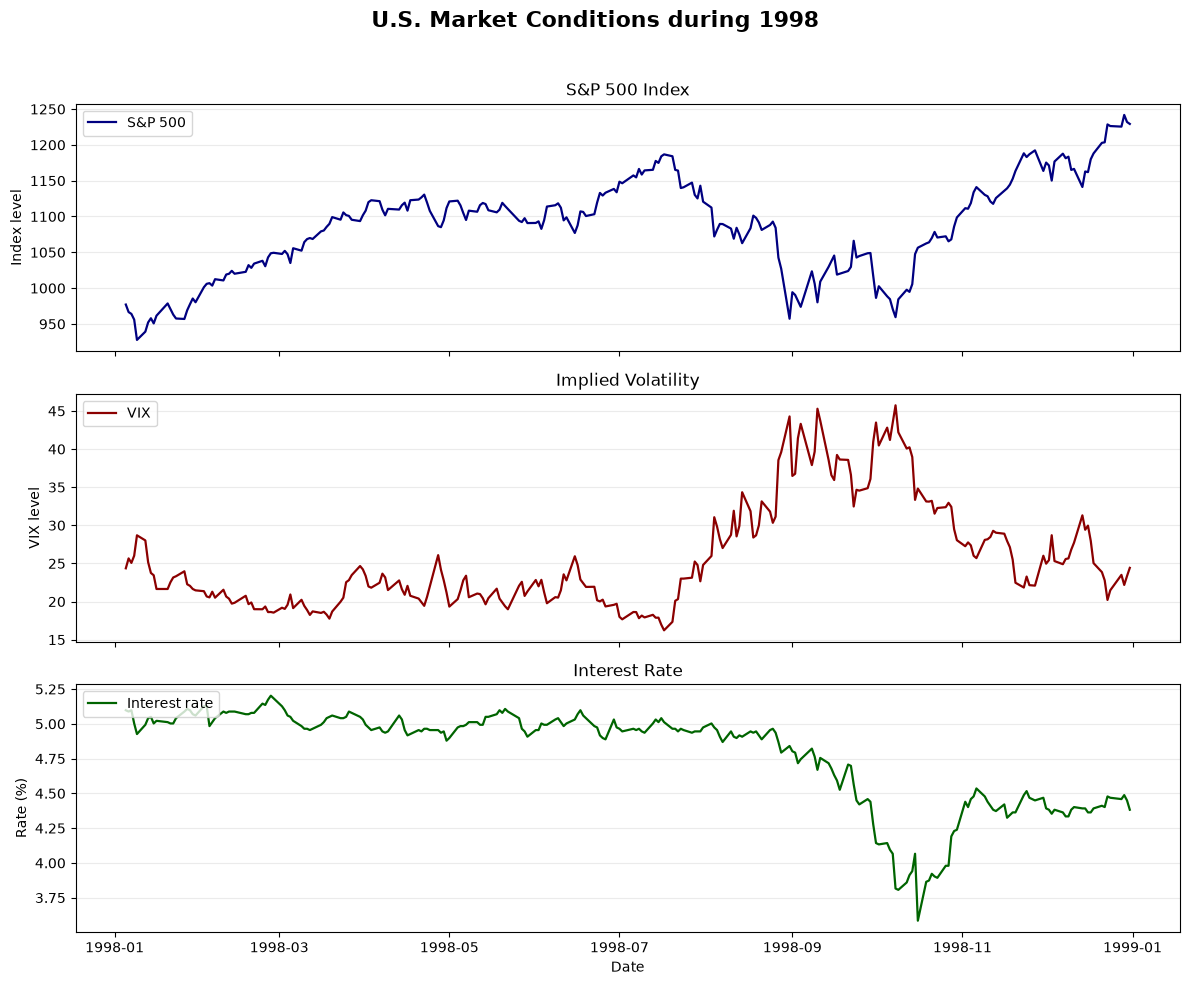

In [6]:
# 1.1 Plot the 1998 market conditions

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 10),
    sharex=True
)
fig.suptitle(
    "U.S. Market Conditions during 1998",
    fontsize=16,
    fontweight="bold"
)
axes[0].plot(
    market_data["date"],
    market_data["sp500"],
    color="navy",
    linewidth=1.6,
    label="S&P 500"
)
axes[0].set_title("S&P 500 Index")
axes[0].set_ylabel("Index level")
axes[0].legend(
    loc="upper left"
)
axes[0].grid(
    axis="y",
    alpha=0.25
)
axes[1].plot(
    market_data["date"],
    market_data["vix"],
    color="darkred",
    linewidth=1.6,
    label="VIX"
)
axes[1].set_title("Implied Volatility")
axes[1].set_ylabel("VIX level")
axes[1].legend(
    loc="upper left"
)

axes[1].grid(
    axis="y",
    alpha=0.25
)
axes[2].plot(
    market_data["date"],
    market_data["rate"] * 100,
    color="darkgreen",
    linewidth=1.6,
    label="Interest rate"
)
axes[2].set_title("Interest Rate")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Rate (%)")
axes[2].legend(
    loc="upper left"
)

axes[2].grid(
    axis="y",
    alpha=0.25
)
plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)
FIGURES_FOLDER = Path("figures")
FIGURES_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)
print(f"Figures folder: {FIGURES_FOLDER.as_posix()}")
plt.savefig(
    FIGURES_FOLDER / "market_conditions_1998.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 2. Black-Scholes pricing and option Greeks

The Black-Scholes model is used to calculate the theoretical value and risk exposures of a European call option.

The call price is:  C = S N(d_1) - K e^{-rT}N(d_2)

where:
- d_1 =\frac{\ln(S/K)+(r+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}
- d_2 = d_1-\sigma\sqrt{T}

The model also provides the option's delta, gamma, and vega. Following the assignment, the dividend yield of the S&P 500 is ignored.

In [7]:
# 2.0 Define the Black-Scholes call function

def black_scholes_call(S, K, T, r, sigma):
    if S <= 0:
        raise ValueError("The underlying price must be positive.")

    if K <= 0:
        raise ValueError("The strike price must be positive.")

    if T <= 0:
        raise ValueError("Time to expiration must be positive.")

    if sigma <= 0:
        raise ValueError("Volatility must be positive.")

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T)

    return {
        "d1": d1,
        "d2": d2,
        "price": call_price,
        "delta": delta,
        "gamma": gamma,
        "vega": vega
    }

### 2.1 Initial option pricing and trade economics

On 5 January 1998, LTCM sells 700,000 five-year European call options on the S&P 500 with a strike price of 1,000.

The theoretical fair value is calculated using the observed market volatility. The client price is calculated by multiplying the observed volatility by 1.25.

The difference between the quoted price and the fair value represents the upfront profit earned by LTCM. Initial capital is assumed to equal 25% of the quoted option price.

In [8]:
# 2.1 Set the initial transaction parameters
initial_observation = market_data.iloc[0]

S0 = initial_observation["sp500"]
sigma0 = initial_observation["sigma"]
r0 = initial_observation["rate"]

K = 1000.0
T0 = 5.0
NUMBER_OF_OPTIONS = 700_000
VOLATILITY_MARKUP = 1.25
CAPITAL_RATE = 0.25

print(f"Date: {initial_observation['date']:%d %B %Y}")
print(f"S&P 500: {S0:,.2f}")
print(f"Volatility: {sigma0:.2%}")
print(f"Interest rate: {r0:.4%}")
print(f"Strike: {K:,.2f}")
print(f"Maturity: {T0:.1f} years")
print(f"Number of options: {NUMBER_OF_OPTIONS:,}")

Date: 05 January 1998
S&P 500: 977.07
Volatility: 24.36%
Interest rate: 5.0978%
Strike: 1,000.00
Maturity: 5.0 years
Number of options: 700,000


In [9]:
# 2.2 Calculate the fair and quoted option values
fair_call = black_scholes_call(S0, K, T0, r0, sigma0)

quoted_sigma = sigma0 * VOLATILITY_MARKUP
quoted_call = black_scholes_call(S0, K, T0, r0, quoted_sigma)

print(f"Fair volatility: {sigma0:.2%}")
print(f"Quoted volatility: {quoted_sigma:.2%}")
print(f"Fair call value: ${fair_call['price']:,.6f}")
print(f"Quoted call value: ${quoted_call['price']:,.6f}")

Fair volatility: 24.36%
Quoted volatility: 30.45%
Fair call value: $305.333074
Quoted call value: $347.282779


In [10]:
# 2.3 Calculate upfront profit and initial NAV
upfront_profit_per_option = quoted_call["price"] - fair_call["price"]
total_upfront_profit = upfront_profit_per_option * NUMBER_OF_OPTIONS

initial_capital_per_option = CAPITAL_RATE * quoted_call["price"]
total_initial_capital = initial_capital_per_option * NUMBER_OF_OPTIONS

initial_nav_per_option = upfront_profit_per_option + initial_capital_per_option
total_initial_nav = initial_nav_per_option * NUMBER_OF_OPTIONS

print(f"Upfront profit per option: ${upfront_profit_per_option:,.6f}")
print(f"Total upfront profit: ${total_upfront_profit:,.2f}")
print(f"Initial capital per option: ${initial_capital_per_option:,.6f}")
print(f"Total initial capital: ${total_initial_capital:,.2f}")
print(f"Initial NAV per option: ${initial_nav_per_option:,.6f}")
print(f"Total initial NAV: ${total_initial_nav:,.2f}")

Upfront profit per option: $41.949705
Total upfront profit: $29,364,793.27
Initial capital per option: $86.820695
Total initial capital: $60,774,486.33
Initial NAV per option: $128.770399
Total initial NAV: $90,139,279.60


In [11]:
# 2.4 Reconcile the Python results with Excel
q2_reconciliation = pd.DataFrame({
    "Excel": [
        305.333074345528,
        347.282779013637,
        29_364_793.267677,
        128.770399421519,
        90_139_279.595063
    ],
    "Python": [
        fair_call["price"],
        quoted_call["price"],
        total_upfront_profit,
        initial_nav_per_option,
        total_initial_nav
    ]
}, index=[
    "Fair call price",
    "Quoted call price",
    "Total upfront profit",
    "Initial NAV per option",
    "Total initial NAV"
])

q2_reconciliation["Difference"] = q2_reconciliation["Python"] - q2_reconciliation["Excel"]

display(q2_reconciliation)

,Excel,Python,Difference
Fair call price,305.333074,305.333074,-0.000000
Quoted call price,347.282779,347.282779,0.000000
Total upfront profit,"29,364,793.267677","29,364,793.267677",-0.000000
Initial NAV per option,128.770399,128.770399,0.000000
Total initial NAV,"90,139,279.595063","90,139,279.595063",0.000000


In [12]:
# 2.5 Validate the Question 2 results
np.testing.assert_allclose(fair_call["price"], 305.333074345528, rtol=0, atol=1e-6)
np.testing.assert_allclose(quoted_call["price"], 347.282779013637, rtol=0, atol=1e-6)
np.testing.assert_allclose(total_upfront_profit, 29_364_793.267677, rtol=0, atol=1e-4)
np.testing.assert_allclose(initial_nav_per_option, 128.770399421519, rtol=0, atol=1e-6)
np.testing.assert_allclose(total_initial_nav, 90_139_279.595063, rtol=0, atol=1e-4)

print("Question 2 successfully reconciled with Excel.")

Question 2 successfully reconciled with Excel.


## 3. Delta-hedging strategy

LTCM has sold a five-year European call option and therefore holds a short option position.

To reduce its exposure to changes in the S&P 500, LTCM implements a dynamic delta hedge. The hedge is rebalanced at every market observation using the option delta calculated by the Black-Scholes model.

The first step is to calculate the option's remaining maturity, fair value, delta, gamma, and vega throughout 1998.

In [13]:
# 3.1 Create the Question 3 dataset

q3 = market_data.copy()

q3["tte"] = T0 - (q3["date"] - q3.loc[0, "date"]).dt.days / 365

display(q3.head())

,date,vix,sp500,sigma,rate,tte
0,1998-01-05,24.360001,977.070007,0.243600,0.050978,5.000000
1,1998-01-06,25.660000,966.580017,0.256600,0.050883,4.997260
2,1998-01-07,25.070000,964.000000,0.250700,0.050978,4.994521
3,1998-01-08,26.010000,956.049988,0.260100,0.050027,4.991781
4,1998-01-09,28.690001,927.690002,0.286900,0.049266,4.989041


In [14]:
# 3.2 Calculate the daily option price and Greeks

option_metrics = q3.apply(lambda row: black_scholes_call(row["sp500"], K, row["tte"], row["rate"], row["sigma"]), axis=1)

option_metrics = pd.DataFrame(option_metrics.tolist(), index=q3.index)

option_metrics = option_metrics.rename(columns={"price": "call_price"})

q3 = pd.concat([q3, option_metrics], axis=1)

display(q3[["date", "sp500", "sigma", "rate", "tte", "call_price", "delta", "gamma", "vega"]].head())

,date,sp500,sigma,rate,tte,call_price,delta,gamma,vega
0,1998-01-05,977.070007,0.243600,0.050978,5.000000,305.333074,0.757321,0.000588,683.303739
1,1998-01-06,966.580017,0.256600,0.050883,4.997260,306.043596,0.748838,0.000575,688.323692
2,1998-01-07,964.000000,0.250700,0.050978,4.994521,300.147604,0.748297,0.000590,687.079399
3,1998-01-08,956.049988,0.260100,0.050027,4.991781,298.644923,0.739872,0.000584,693.031548
4,1998-01-09,927.690002,0.286900,0.049266,4.989041,294.976648,0.721345,0.000565,695.888999


In [15]:
# 3.3 Inspect the initial and final option values

q3_checkpoints = q3.loc[
    [q3.index[0], q3.index[-1]],
    ["date", "sp500", "sigma", "rate", "tte", "call_price", "delta", "gamma", "vega"]
]

display(q3_checkpoints)

,date,sp500,sigma,rate,tte,call_price,delta,gamma,vega
0,1998-01-05,977.070007,0.243600,0.050978,5.000000,305.333074,0.757321,0.000588,683.303739
250,1998-12-31,"1,229.229980",0.244200,0.043825,4.013699,451.155400,0.847559,0.000392,580.390888


In [16]:
# 3.4 Validate the daily option calculations

np.testing.assert_allclose(q3.loc[0, "tte"], 5.0, rtol=0, atol=1e-10)
np.testing.assert_allclose(q3.loc[0, "call_price"], 305.333074345528, rtol=0, atol=1e-6)
np.testing.assert_allclose(q3.loc[0, "delta"], 0.757320548520, rtol=0, atol=1e-6)
np.testing.assert_allclose(q3.loc[q3.index[-1], "tte"], 4.013698630137, rtol=0, atol=1e-10)
np.testing.assert_allclose(q3.loc[q3.index[-1], "call_price"], 451.155399767436, rtol=0, atol=1e-6)

print("Daily option values and Greeks successfully reconciled with Excel.")

Daily option values and Greeks successfully reconciled with Excel.


### 3.1 Self-financing delta hedge

Because LTCM is short the client call, it buys a positive quantity of the S&P 500 equal to the option delta.

At every observation, the stock position is rebalanced using the new Black-Scholes delta. The purchase or sale of stock is financed through the cash account.

Between two observations, the previous cash balance accrues interest and the previous stock position generates the hedge P&L.

In [17]:
# 3.5 Calculate the change in the client liability and the stock hedge

q3["client_liability_change"] = q3["call_price"].diff().fillna(0.0)
q3["stock_units"] = q3["delta"]
q3["stock_position"] = q3["stock_units"] * q3["sp500"]
q3["rebalancing_cost"] = (q3["stock_units"] - q3["stock_units"].shift(1)) * q3["sp500"]
q3.loc[0, "rebalancing_cost"] = 0.0
q3["stock_hedge_pnl"] = q3["stock_units"].shift(1) * (q3["sp500"] - q3["sp500"].shift(1))
q3["stock_hedge_pnl"] = q3["stock_hedge_pnl"].fillna(0.0)
q3["cumulative_client_liability_change"] = q3["client_liability_change"].cumsum()
q3["cumulative_hedge_pnl"] = q3["stock_hedge_pnl"].cumsum()
q3["moneyness"] = q3["sp500"] / K

display(
    q3[[
        "date",
        "call_price",
        "client_liability_change",
        "delta",
        "stock_units",
        "stock_position",
        "rebalancing_cost",
        "stock_hedge_pnl"
    ]].head()
)


,date,call_price,client_liability_change,delta,stock_units,stock_position,rebalancing_cost,stock_hedge_pnl
0,1998-01-05,305.333074,0.000000,0.757321,0.757321,739.955194,0.000000,0.000000
1,1998-01-06,306.043596,0.710522,0.748838,0.748838,723.811717,-8.199192,-7.944285
2,1998-01-07,300.147604,-5.895992,0.748297,0.748297,721.357967,-0.521735,-1.932014
3,1998-01-08,298.644923,-1.502681,0.739872,0.739872,707.354432,-8.054568,-5.948967
4,1998-01-09,294.976648,-3.668275,0.721345,0.721345,669.184109,-17.187569,-20.982754


In [18]:
# 3.6 Initialize the cash account

q3["interest_accrual"] = 0.0
q3["cash_account"] = np.nan

q3.loc[0, "cash_account"] = quoted_call["price"] + initial_capital_per_option - q3.loc[0, "stock_position"]

print(f"Initial client premium: ${quoted_call['price']:,.6f}")
print(f"Initial capital: ${initial_capital_per_option:,.6f}")
print(f"Initial stock purchase: ${q3.loc[0, 'stock_position']:,.6f}")
print(f"Initial cash account: ${q3.loc[0, 'cash_account']:,.6f}")

Initial client premium: $347.282779
Initial capital: $86.820695
Initial stock purchase: $739.955194
Initial cash account: $-305.851720


In [19]:
# 3.7 Update interest and cash through time

for i in range(1, len(q3)):
    elapsed_days = (q3.loc[i, "date"] - q3.loc[i - 1, "date"]).days
    q3.loc[i, "interest_accrual"] = q3.loc[i - 1, "cash_account"] * (np.exp(q3.loc[i - 1, "rate"] * elapsed_days / 365) - 1)
    q3.loc[i, "cash_account"] = q3.loc[i - 1, "cash_account"] + q3.loc[i, "interest_accrual"] - q3.loc[i, "rebalancing_cost"]

display(q3[[
    "date",
    "rebalancing_cost",
    "interest_accrual",
    "cash_account"
]].head())

,date,rebalancing_cost,interest_accrual,cash_account
0,1998-01-05,0.000000,0.000000,-305.851720
1,1998-01-06,-8.199192,-0.042720,-297.695248
2,1998-01-07,-0.521735,-0.041503,-297.215016
3,1998-01-08,-8.054568,-0.041514,-289.201962
4,1998-01-09,-17.187569,-0.039641,-272.054034


In [20]:
# 3.8 Calculate NAV and the self-financing check

q3["nav"] = q3["cash_account"] + q3["stock_position"] - q3["call_price"]
q3["self_financing_check"] = q3["nav"].diff() - (q3["interest_accrual"] + q3["stock_hedge_pnl"] - q3["client_liability_change"])
q3.loc[0, "self_financing_check"] = 0.0

display(
    q3[[
        "date",
        "cash_account",
        "stock_position",
        "call_price",
        "nav",
        "self_financing_check"
    ]].head()
)


,date,cash_account,stock_position,call_price,nav,self_financing_check
0,1998-01-05,-305.851720,739.955194,305.333074,128.770399,0.000000
1,1998-01-06,-297.695248,723.811717,306.043596,120.072872,0.000000
2,1998-01-07,-297.215016,721.357967,300.147604,123.995346,0.000000
3,1998-01-08,-289.201962,707.354432,298.644923,119.507547,-0.000000
4,1998-01-09,-272.054034,669.184109,294.976648,102.153427,-0.000000


In [21]:
# 3.9 Identify the main NAV events

negative_nav_observations = q3.loc[q3["nav"] < 0]

first_negative_date = negative_nav_observations.iloc[0]["date"] if not negative_nav_observations.empty else pd.NaT
minimum_nav_index = q3["nav"].idxmin()
minimum_nav_date = q3.loc[minimum_nav_index, "date"]

q3_events = pd.DataFrame({
    "Event": [
        "Initial",
        "First negative NAV",
        "Minimum NAV",
        "30 September",
        "Final"
    ],
    "date": [
        q3.loc[0, "date"],
        first_negative_date,
        minimum_nav_date,
        pd.Timestamp("1998-09-30"),
        q3.loc[q3.index[-1], "date"]
    ]
})

q3_event_summary = q3_events.merge(
    q3[[
        "date",
        "sp500",
        "sigma",
        "rate",
        "call_price",
        "cash_account",
        "nav"
    ]],
    on="date",
    how="left"
)

q3_event_summary = q3_event_summary.set_index("Event")

display(q3_event_summary)

,date,sp500,sigma,rate,call_price,cash_account,nav
Event,,,,,,,
Initial,1998-01-05,977.070007,0.243600,0.050978,305.333074,-305.851720,128.770399
First negative NAV,NaT,NaN,NaN,NaN,NaN,NaN,NaN
Minimum NAV,1998-09-10,980.190002,0.452900,0.046693,412.509548,-310.186894,9.085607
30 September,1998-09-30,"1,017.010010",0.409500,0.042772,402.838871,-309.680124,45.060888
Final,1998-12-31,"1,229.229980",0.244200,0.043825,451.155400,-433.896948,156.792751


In [22]:
# 3.10 Validate the Question 3 results

q3_initial_nav = q3.loc[q3["date"].eq(pd.Timestamp("1998-01-05")), "nav"].iloc[0]
q3_september_nav = q3.loc[q3["date"].eq(pd.Timestamp("1998-09-30")), "nav"].iloc[0]
q3_final_nav = q3.loc[q3["date"].eq(pd.Timestamp("1998-12-31")), "nav"].iloc[0]

maximum_self_financing_error = q3["self_financing_check"].abs().max()

np.testing.assert_allclose(q3_initial_nav, 128.770399421519, rtol=0, atol=1e-6)
np.testing.assert_allclose(q3_september_nav, 45.060888497562, rtol=0, atol=1e-6)
np.testing.assert_allclose(q3_final_nav, 156.792750621277, rtol=0, atol=1e-6)

assert maximum_self_financing_error < 1e-10

print(f"Maximum self-financing error: {maximum_self_financing_error:.12e}")
print("Question 3 successfully reconciled with Excel.")

Maximum self-financing error: 1.953992523340e-13
Question 3 successfully reconciled with Excel.


### 3.2 Delta-hedging results

The following charts examine the performance and risk exposures of the delta-hedged short call position.

They compare the cumulative change in the client option liability with the stock hedge P&L and show how delta, gamma, and vega evolved with the underlying market variables.

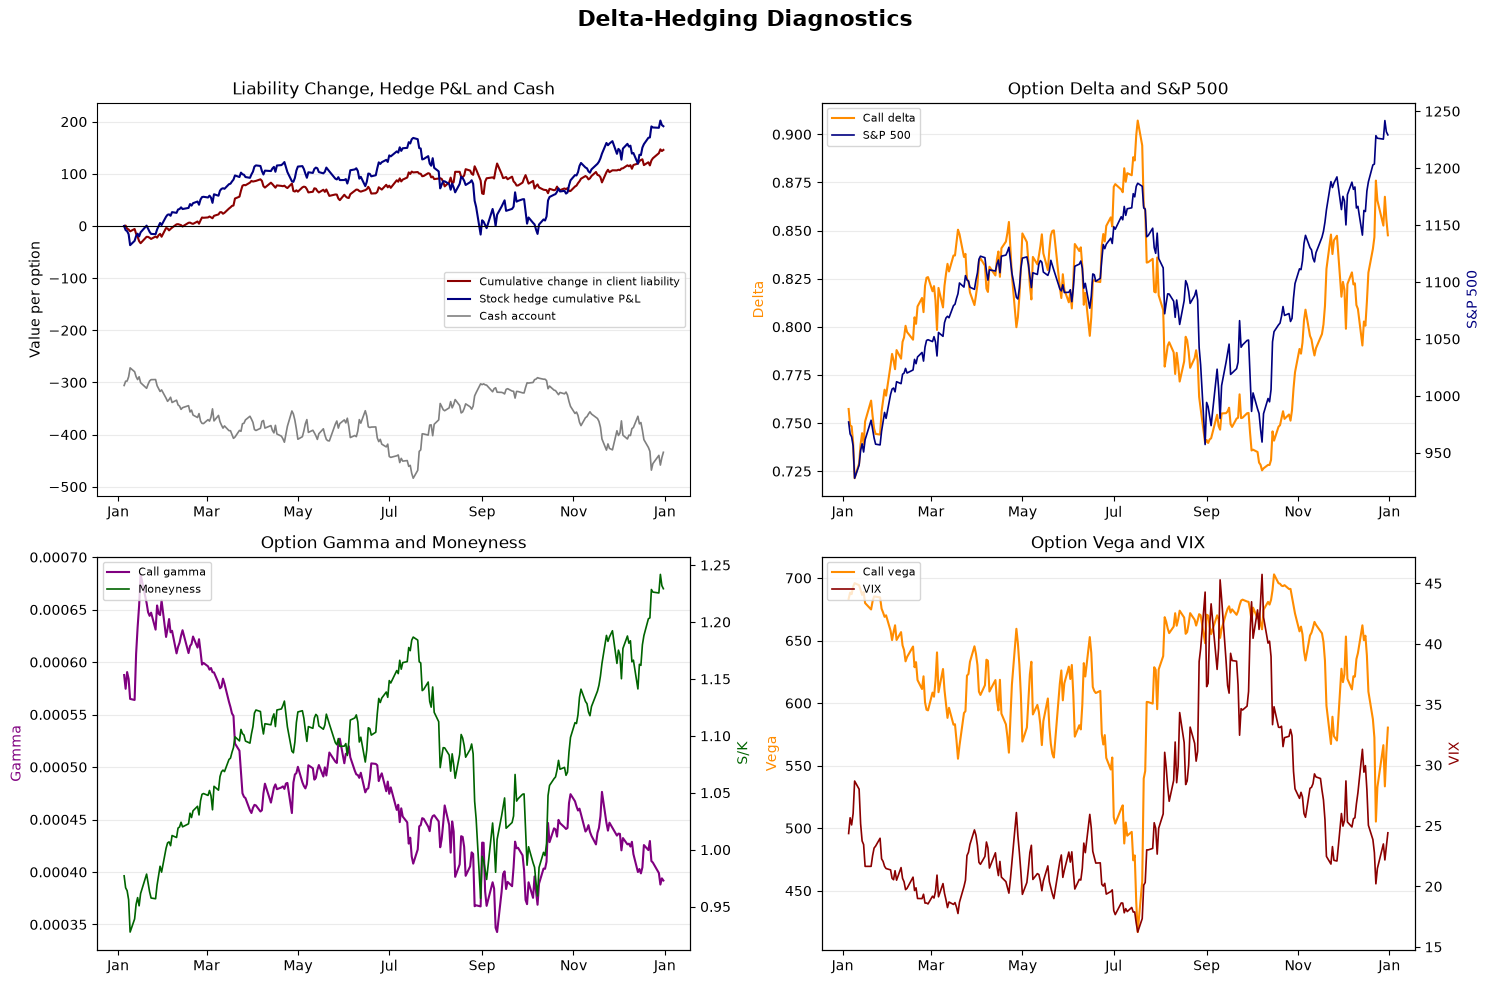

In [23]:
# 3.11 Plot the delta-hedging diagnostics


fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 10)
)

fig.suptitle(
    "Delta-Hedging Diagnostics",
    fontsize=16,
    fontweight="bold"
)

axes[0, 0].plot(
    q3["date"],
    q3["cumulative_client_liability_change"],
    color="darkred",
    linewidth=1.5,
    label="Cumulative change in client liability"
)

axes[0, 0].plot(
    q3["date"],
    q3["cumulative_hedge_pnl"],
    color="navy",
    linewidth=1.5,
    label="Stock hedge cumulative P&L"
)

axes[0, 0].plot(
    q3["date"],
    q3["cash_account"],
    color="gray",
    linewidth=1.2,
    label="Cash account"
)

axes[0, 0].axhline(
    0,
    color="black",
    linewidth=0.8
)

axes[0, 0].set_title("Liability Change, Hedge P&L and Cash")
axes[0, 0].set_ylabel("Value per option")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(axis="y", alpha=0.25)


delta_axis = axes[0, 1]
index_axis = delta_axis.twinx()

delta_line = delta_axis.plot(
    q3["date"],
    q3["delta"],
    color="darkorange",
    linewidth=1.5,
    label="Call delta"
)

index_line = index_axis.plot(
    q3["date"],
    q3["sp500"],
    color="navy",
    linewidth=1.2,
    label="S&P 500"
)

delta_axis.set_title("Option Delta and S&P 500")
delta_axis.set_ylabel("Delta", color="darkorange")
index_axis.set_ylabel("S&P 500", color="navy")
delta_axis.grid(axis="y", alpha=0.25)

combined_lines = delta_line + index_line
combined_labels = [line.get_label() for line in combined_lines]

delta_axis.legend(
    combined_lines,
    combined_labels,
    loc="upper left",
    fontsize=8
)


gamma_axis = axes[1, 0]
moneyness_axis = gamma_axis.twinx()

gamma_line = gamma_axis.plot(
    q3["date"],
    q3["gamma"],
    color="purple",
    linewidth=1.5,
    label="Call gamma"
)

moneyness_line = moneyness_axis.plot(
    q3["date"],
    q3["moneyness"],
    color="darkgreen",
    linewidth=1.2,
    label="Moneyness"
)

gamma_axis.set_title("Option Gamma and Moneyness")
gamma_axis.set_ylabel("Gamma", color="purple")
moneyness_axis.set_ylabel("S/K", color="darkgreen")
gamma_axis.grid(axis="y", alpha=0.25)

combined_lines = gamma_line + moneyness_line
combined_labels = [line.get_label() for line in combined_lines]

gamma_axis.legend(
    combined_lines,
    combined_labels,
    loc="upper left",
    fontsize=8
)


vega_axis = axes[1, 1]
vix_axis = vega_axis.twinx()

vega_line = vega_axis.plot(
    q3["date"],
    q3["vega"],
    color="darkorange",
    linewidth=1.5,
    label="Call vega"
)

vix_line = vix_axis.plot(
    q3["date"],
    q3["vix"],
    color="darkred",
    linewidth=1.2,
    label="VIX"
)

vega_axis.set_title("Option Vega and VIX")
vega_axis.set_ylabel("Vega", color="darkorange")
vix_axis.set_ylabel("VIX", color="darkred")
vega_axis.grid(axis="y", alpha=0.25)

combined_lines = vega_line + vix_line
combined_labels = [line.get_label() for line in combined_lines]

vega_axis.legend(
    combined_lines,
    combined_labels,
    loc="upper left",
    fontsize=8
)


for axis in axes.flat:
    axis.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    FIGURES_FOLDER / "q3_delta_hedging_diagnostics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

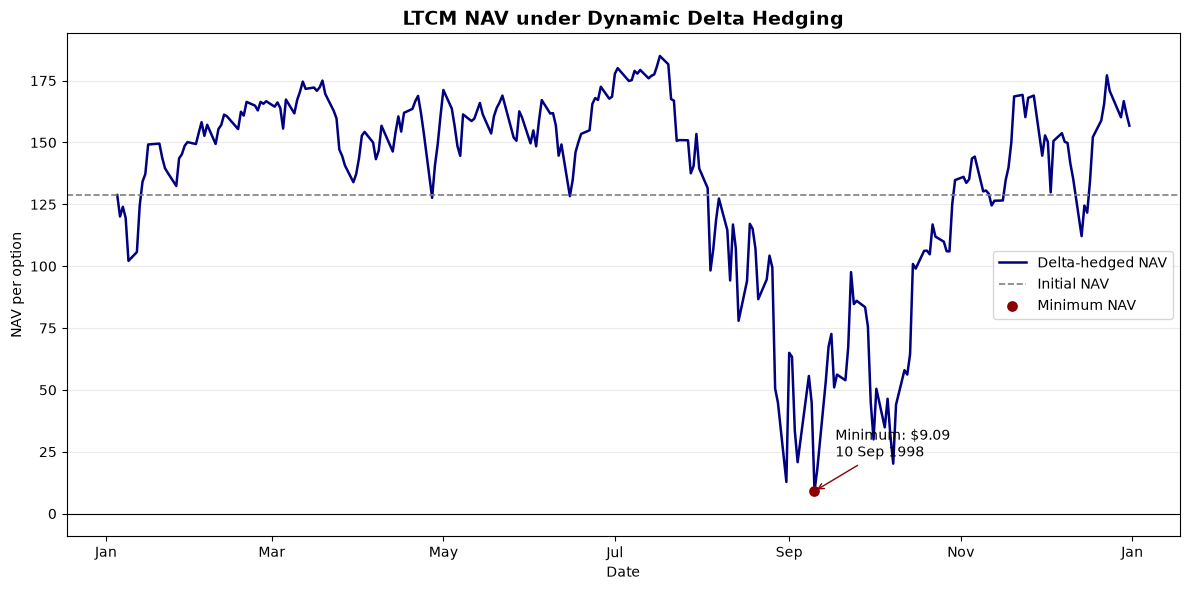

In [24]:
# 3.12 Plot the fund NAV under delta hedging

minimum_nav = q3.loc[minimum_nav_index, "nav"]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    q3["date"],
    q3["nav"],
    color="navy",
    linewidth=1.8,
    label="Delta-hedged NAV"
)

ax.axhline(
    initial_nav_per_option,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Initial NAV"
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax.scatter(
    minimum_nav_date,
    minimum_nav,
    color="darkred",
    s=45,
    zorder=3,
    label="Minimum NAV"
)

ax.annotate(
    f"Minimum: ${minimum_nav:,.2f}\n{minimum_nav_date:%d %b %Y}",
    xy=(minimum_nav_date, minimum_nav),
    xytext=(15, 25),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": "darkred"
    }
)

ax.set_title(
    "LTCM NAV under Dynamic Delta Hedging",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("NAV per option")
ax.legend()
ax.grid(axis="y", alpha=0.25)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

plt.tight_layout()

plt.savefig(
    FIGURES_FOLDER / "q3_delta_hedged_nav.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Counterfactual analysis

The actual 1998 results reflect simultaneous changes in the S&P 500, volatility, and interest rates.

To isolate the contribution of individual market variables, two counterfactual scenarios are considered:

1. Interest rates remain constant at their initial observed level.
2. Volatility remains constant at its initial observed level.

In each scenario, all other market variables continue to follow their historical paths.

In [25]:
# 4.1 Define a reusable delta-hedging function

def run_delta_hedge(data, rate_path, sigma_path, strike, maturity, initial_premium, initial_capital):
    model = data.copy()

    model["model_rate"] = np.asarray(rate_path, dtype=float)
    model["model_sigma"] = np.asarray(sigma_path, dtype=float)
    model["tte"] = maturity - (model["date"] - model.loc[0, "date"]).dt.days / 365

    option_metrics = model.apply(lambda row: black_scholes_call(row["sp500"], strike, row["tte"], row["model_rate"], row["model_sigma"]), axis=1)
    option_metrics = pd.DataFrame(option_metrics.tolist(), index=model.index)
    option_metrics = option_metrics.rename(columns={"price": "call_price"})

    model = pd.concat([model, option_metrics], axis=1)

    model["client_mtm_pnl"] = model["call_price"].diff().fillna(0.0)
    model["stock_units"] = model["delta"]
    model["stock_position"] = model["stock_units"] * model["sp500"]

    model["rebalancing_cost"] = (model["stock_units"] - model["stock_units"].shift(1)) * model["sp500"]
    model.loc[0, "rebalancing_cost"] = 0.0

    model["stock_hedge_pnl"] = model["stock_units"].shift(1) * (model["sp500"] - model["sp500"].shift(1))
    model["stock_hedge_pnl"] = model["stock_hedge_pnl"].fillna(0.0)

    model["cumulative_client_pnl"] = model["client_mtm_pnl"].cumsum()
    model["cumulative_hedge_pnl"] = model["stock_hedge_pnl"].cumsum()
    model["moneyness"] = model["sp500"] / strike

    model["interest_accrual"] = 0.0
    model["cash_account"] = np.nan
    model.loc[0, "cash_account"] = initial_premium + initial_capital - model.loc[0, "stock_position"]

    for i in range(1, len(model)):
        elapsed_days = (model.loc[i, "date"] - model.loc[i - 1, "date"]).days
        model.loc[i, "interest_accrual"] = model.loc[i - 1, "cash_account"] * (np.exp(model.loc[i - 1, "model_rate"] * elapsed_days / 365) - 1)
        model.loc[i, "cash_account"] = model.loc[i - 1, "cash_account"] + model.loc[i, "interest_accrual"] - model.loc[i, "rebalancing_cost"]

    model["nav"] = model["cash_account"] + model["stock_position"] - model["call_price"]
    model["self_financing_check"] = model["nav"].diff() - (model["interest_accrual"] + model["stock_hedge_pnl"] - model["client_mtm_pnl"])
    model.loc[0, "self_financing_check"] = 0.0

    return model

In [26]:
# 4.2 Validate the reusable function against Question 3

q3_function_check = run_delta_hedge(
    data=market_data,
    rate_path=market_data["rate"],
    sigma_path=market_data["sigma"],
    strike=K,
    maturity=T0,
    initial_premium=quoted_call["price"],
    initial_capital=initial_capital_per_option
)

maximum_q3_difference = np.max(np.abs(q3_function_check["nav"] - q3["nav"]))

print(f"Maximum difference from Question 3: {maximum_q3_difference:.12e}")

assert maximum_q3_difference < 1e-10

Maximum difference from Question 3: 0.000000000000e+00


In [27]:
# 4.3 Run the constant-interest-rate counterfactual

fixed_rate_path = np.full(len(market_data), r0)

q4_fixed_rate = run_delta_hedge(
    data=market_data,
    rate_path=fixed_rate_path,
    sigma_path=market_data["sigma"],
    strike=K,
    maturity=T0,
    initial_premium=quoted_call["price"],
    initial_capital=initial_capital_per_option
)

display(q4_fixed_rate[[
    "date",
    "model_rate",
    "model_sigma",
    "call_price",
    "cash_account",
    "nav"
]].head())

,date,model_rate,model_sigma,call_price,cash_account,nav
0,1998-01-05,0.050978,0.243600,305.333074,-305.851720,128.770399
1,1998-01-06,0.050978,0.256600,306.242014,-297.950107,119.874455
2,1998-01-07,0.050978,0.250700,300.147604,-297.215810,123.994553
3,1998-01-08,0.050978,0.260100,300.586030,-291.729346,117.565646
4,1998-01-09,0.050978,0.286900,298.176876,-276.267106,98.876350


In [28]:
# 4.4 Run the constant-volatility counterfactual

fixed_volatility_path = np.full(len(market_data), sigma0)

q4_fixed_volatility = run_delta_hedge(
    data=market_data,
    rate_path=market_data["rate"],
    sigma_path=fixed_volatility_path,
    strike=K,
    maturity=T0,
    initial_premium=quoted_call["price"],
    initial_capital=initial_capital_per_option
)

display(q4_fixed_volatility[[
    "date",
    "model_rate",
    "model_sigma",
    "call_price",
    "cash_account",
    "nav"
]].head())

,date,model_rate,model_sigma,call_price,cash_account,nav
0,1998-01-05,0.050978,0.243600,305.333074,-305.851720,128.770399
1,1998-01-06,0.050883,0.243600,297.112255,-299.527850,129.004214
2,1998-01-07,0.050978,0.243600,295.274731,-298.265557,128.863072
3,1998-01-08,0.050027,0.243600,287.228005,-290.899201,130.910549
4,1998-01-09,0.049266,0.243600,264.813034,-271.806444,132.252959


In [29]:
# 4.5 Compare the actual and counterfactual NAV results

comparison_dates = pd.to_datetime([
    "1998-01-05",
    "1998-09-10",
    "1998-09-30",
    "1998-12-31"
])

q4_comparison = pd.DataFrame({
    "Actual": q3.set_index("date").loc[comparison_dates, "nav"],
    "Fixed rate": q4_fixed_rate.set_index("date").loc[comparison_dates, "nav"],
    "Fixed volatility": q4_fixed_volatility.set_index("date").loc[comparison_dates, "nav"]
})

q4_comparison.index = [
    "Initial",
    "10 September",
    "30 September",
    "Final"
]

display(q4_comparison)

,Actual,Fixed rate,Fixed volatility
Initial,128.770399,128.770399,128.770399
10 September,9.085607,2.520303,146.080719
30 September,45.060888,31.837147,154.112358
Final,156.792751,141.927539,153.801411


In [30]:
# 4.6 Validate the counterfactual results

fixed_rate_september_nav = q4_fixed_rate.loc[q4_fixed_rate["date"].eq(pd.Timestamp("1998-09-30")), "nav"].iloc[0]
fixed_rate_final_nav = q4_fixed_rate.loc[q4_fixed_rate["date"].eq(pd.Timestamp("1998-12-31")), "nav"].iloc[0]

fixed_volatility_september_nav = q4_fixed_volatility.loc[q4_fixed_volatility["date"].eq(pd.Timestamp("1998-09-30")), "nav"].iloc[0]
fixed_volatility_final_nav = q4_fixed_volatility.loc[q4_fixed_volatility["date"].eq(pd.Timestamp("1998-12-31")), "nav"].iloc[0]

np.testing.assert_allclose(fixed_rate_september_nav, 31.837147065428, rtol=0, atol=1e-6)
np.testing.assert_allclose(fixed_rate_final_nav, 141.927538508264, rtol=0, atol=1e-6)
np.testing.assert_allclose(fixed_volatility_september_nav, 154.112358367910, rtol=0, atol=1e-6)
np.testing.assert_allclose(fixed_volatility_final_nav, 153.801410861554, rtol=0, atol=1e-6)

assert q4_fixed_rate["self_financing_check"].abs().max() < 1e-10
assert q4_fixed_volatility["self_financing_check"].abs().max() < 1e-10

print("Question 4 successfully reconciled with Excel.")

Question 4 successfully reconciled with Excel.


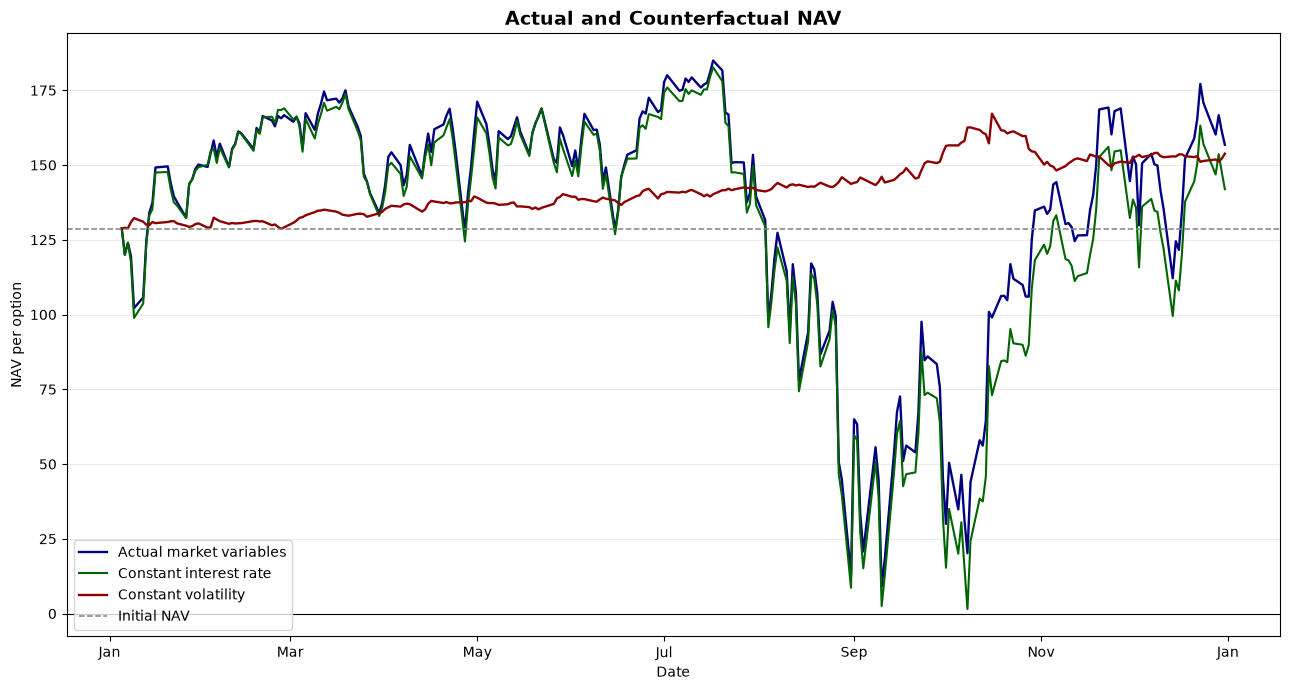

In [31]:
# 4.7 Plot the actual and counterfactual NAV paths

fig, ax = plt.subplots(
    figsize=(13, 7)
)

ax.plot(
    q3["date"],
    q3["nav"],
    color="navy",
    linewidth=1.7,
    label="Actual market variables"
)

ax.plot(
    q4_fixed_rate["date"],
    q4_fixed_rate["nav"],
    color="darkgreen",
    linewidth=1.5,
    label="Constant interest rate"
)

ax.plot(
    q4_fixed_volatility["date"],
    q4_fixed_volatility["nav"],
    color="darkred",
    linewidth=1.7,
    label="Constant volatility"
)

ax.axhline(
    initial_nav_per_option,
    color="gray",
    linestyle="--",
    linewidth=1.1,
    label="Initial NAV"
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Actual and Counterfactual NAV",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("NAV per option")
ax.legend()
ax.grid(axis="y", alpha=0.25)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

plt.tight_layout()

plt.savefig(
    FIGURES_FOLDER / "q4_counterfactual_nav.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Delta and vega hedging strategy

The delta hedge protects LTCM against small changes in the S&P 500 but does not eliminate its exposure to changes in implied volatility.

To reduce this exposure, LTCM buys one-year at-the-money calls. The quantity purchased is chosen so that the total portfolio vega equals zero on each roll date.

The hedge call is held for 20 trading intervals. On observations 21, 41, 61, and so on, the old call is sold and the new call is purchased simultaneously. This avoids any intentional one-day gap in the vega hedge.

The stock position is then adjusted to neutralize the combined delta of the short client call and the long hedge calls.

In [32]:
# 5.1 Define the delta-vega hedging function

def run_delta_vega_hedge(market_data_input, initial_premium, initial_capital, client_strike, client_initial_maturity, roll_interval=20):
    results = market_data_input[["date", "sp500", "sigma", "rate"]].copy()
    results = results.sort_values("date").reset_index(drop=True)
    results["observation"] = np.arange(1, len(results) + 1)
    results["action"] = np.where(results["observation"] == 1, "BUY", np.where((results["observation"] > 1) & ((results["observation"] - 1) % roll_interval == 0), "ROLL", "HOLD"))

    initial_date = results["date"].iloc[0]
    records = []
    previous_cash = 0.0
    previous_stock_units = 0.0
    previous_hedge_quantity = 0.0
    previous_hedge_price = 0.0
    previous_client_price = 0.0
    previous_nav = 0.0
    previous_sp500 = 0.0
    previous_date = None
    previous_rate = None
    hedge_start_date = None
    hedge_strike = None

    for index, row in results.iterrows():
        current_date = row["date"]
        S = float(row["sp500"])
        sigma = float(row["sigma"])
        r = float(row["rate"])
        client_maturity = client_initial_maturity - (current_date - initial_date).days / 365
        client_metrics = black_scholes_call(S, client_strike, client_maturity, r, sigma)

        if index == 0:
            old_hedge_price = 0.0
            old_hedge_delta = 0.0
            old_hedge_gamma = 0.0
            old_hedge_vega = 0.0
            hedge_quantity_sold = 0.0
        else:
            old_hedge_maturity = 1.0 - (current_date - hedge_start_date).days / 365
            old_hedge_metrics = black_scholes_call(S, hedge_strike, old_hedge_maturity, r, sigma)
            old_hedge_price = old_hedge_metrics["price"]
            old_hedge_delta = old_hedge_metrics["delta"]
            old_hedge_gamma = old_hedge_metrics["gamma"]
            old_hedge_vega = old_hedge_metrics["vega"]
            hedge_quantity_sold = previous_hedge_quantity if row["action"] == "ROLL" else 0.0

        if row["action"] in ["BUY", "ROLL"]:
            new_hedge_metrics = black_scholes_call(S, S, 1.0, r, sigma)
            hedge_quantity_bought = client_metrics["vega"] / new_hedge_metrics["vega"]
            hedge_quantity_end = hedge_quantity_bought
            hedge_start_date = current_date
            hedge_strike = S
            hedge_price = new_hedge_metrics["price"]
            hedge_delta = new_hedge_metrics["delta"]
            hedge_gamma = new_hedge_metrics["gamma"]
            hedge_vega = new_hedge_metrics["vega"]
        else:
            hedge_quantity_bought = 0.0
            hedge_quantity_end = previous_hedge_quantity
            hedge_price = old_hedge_price
            hedge_delta = old_hedge_delta
            hedge_gamma = old_hedge_gamma
            hedge_vega = old_hedge_vega

        stock_units = client_metrics["delta"] - hedge_quantity_end * hedge_delta
        option_trade_cost = hedge_quantity_bought * hedge_price - hedge_quantity_sold * old_hedge_price
        stock_trade_cost = (stock_units - previous_stock_units) * S

        if index == 0:
            interest_accrual = 0.0
            cash_before_trades = initial_premium + initial_capital
        else:
            elapsed_time = (current_date - previous_date).days / 365
            cash_before_trades = previous_cash * np.exp(previous_rate * elapsed_time)
            interest_accrual = cash_before_trades - previous_cash

        cash_account = cash_before_trades - option_trade_cost - stock_trade_cost
        stock_position = stock_units * S
        hedge_position = hedge_quantity_end * hedge_price
        nav = cash_account + stock_position + hedge_position - client_metrics["price"]
        total_delta = stock_units + hedge_quantity_end * hedge_delta - client_metrics["delta"]
        total_gamma = hedge_quantity_end * hedge_gamma - client_metrics["gamma"]
        total_vega = hedge_quantity_end * hedge_vega - client_metrics["vega"]

        if index == 0:
            stock_hedge_pnl = 0.0
            hedge_option_pnl = 0.0
            client_liability_change = 0.0
            self_financing_check = 0.0
        else:
            stock_hedge_pnl = previous_stock_units * (S - previous_sp500)
            hedge_option_pnl = previous_hedge_quantity * (old_hedge_price - previous_hedge_price)
            client_liability_change = client_metrics["price"] - previous_client_price
            expected_nav_change = interest_accrual + stock_hedge_pnl + hedge_option_pnl - client_liability_change
            self_financing_check = (nav - previous_nav) - expected_nav_change

        records.append(
            {
                "date": current_date,
                "observation": row["observation"],
                "action": row["action"],
                "sp500": S,
                "sigma": sigma,
                "rate": r,
                "client_maturity": client_maturity,
                "client_call_price": client_metrics["price"],
                "client_delta": client_metrics["delta"],
                "client_gamma": client_metrics["gamma"],
                "client_vega": client_metrics["vega"],
                "pre_roll_hedge_price": old_hedge_price,
                "hedge_price": hedge_price,
                "hedge_delta": hedge_delta,
                "hedge_gamma": hedge_gamma,
                "hedge_vega": hedge_vega,
                "hedge_qty_begin": previous_hedge_quantity,
                "hedge_qty_bought": hedge_quantity_bought,
                "hedge_qty_sold": hedge_quantity_sold,
                "hedge_qty_end": hedge_quantity_end,
                "option_trade_cost": option_trade_cost,
                "stock_trade_cost": stock_trade_cost,
                "stock_units": stock_units,
                "stock_position": stock_position,
                "hedge_position": hedge_position,
                "interest_accrual": interest_accrual,
                "stock_hedge_pnl": stock_hedge_pnl,
                "hedge_option_pnl": hedge_option_pnl,
                "client_liability_change": client_liability_change,
                "cash_account": cash_account,
                "nav": nav,
                "total_delta": total_delta,
                "total_gamma": total_gamma,
                "total_vega": total_vega,
                "self_financing_check": self_financing_check
            }
        )

        previous_cash = cash_account
        previous_stock_units = stock_units
        previous_hedge_quantity = hedge_quantity_end
        previous_hedge_price = hedge_price
        previous_client_price = client_metrics["price"]
        previous_nav = nav
        previous_sp500 = S
        previous_date = current_date
        previous_rate = r

    return pd.DataFrame(records)


In [33]:
# 5.2 Run the delta-vega hedging strategy

q5_results = run_delta_vega_hedge(
    market_data_input=market_data,
    initial_premium=quoted_call["price"],
    initial_capital=initial_capital_per_option,
    client_strike=K,
    client_initial_maturity=T0,
    roll_interval=20
)

minimum_nav_row = q5_results.loc[q5_results["nav"].idxmin()]
roll_rows = q5_results.loc[q5_results["action"] == "ROLL"]

print(f"Number of observations: {len(q5_results)}")
print(f"Initial NAV: {q5_results['nav'].iloc[0]:.6f}")
print(f"Final NAV: {q5_results['nav'].iloc[-1]:.6f}")
print(f"Minimum NAV: {minimum_nav_row['nav']:.6f}")
print(f"Minimum NAV date: {minimum_nav_row['date'].date()}")
print(f"Number of rolls: {len(roll_rows)}")


Number of observations: 251
Initial NAV: 128.770399
Final NAV: 98.794031
Minimum NAV: 95.586946
Minimum NAV date: 1998-12-23
Number of rolls: 12


In [34]:
# 5.3 Inspect the first simultaneous roll

first_roll_check = q5_results.loc[
    q5_results["observation"].between(19, 22),
    [
        "date",
        "observation",
        "action",
        "hedge_qty_begin",
        "hedge_qty_bought",
        "hedge_qty_sold",
        "hedge_qty_end",
        "total_vega",
        "option_trade_cost",
        "nav",
        "pre_roll_hedge_price"
    ]
]

display(first_roll_check)


,date,observation,action,hedge_qty_begin,hedge_qty_bought,hedge_qty_sold,hedge_qty_end,total_vega,option_trade_cost,nav,pre_roll_hedge_price
18,1998-01-30,19,HOLD,1.851736,0.000000,0.000000,1.851736,-12.063826,0.000000,128.108633,105.315478
19,1998-02-02,20,HOLD,1.851736,0.000000,0.000000,1.851736,-16.241769,0.000000,127.325691,118.455707
20,1998-02-03,21,ROLL,1.851736,1.723669,1.851736,1.723669,0.000000,-33.822088,127.328862,119.108796
21,1998-02-04,22,HOLD,1.723669,0.000000,0.000000,1.723669,-6.216280,0.000000,129.338808,107.516968


In [35]:
# 5.4 Summarize the delta-vega hedging results

q5_minimum_index = q5_results["nav"].idxmin()
q5_minimum_date = q5_results.loc[q5_minimum_index, "date"]
q5_minimum_nav = q5_results.loc[q5_minimum_index, "nav"]
q5_summary_dates = pd.to_datetime(["1998-01-05", "1998-09-10", "1998-09-30", "1998-12-31"])

q5_summary = q5_results.set_index("date").loc[
    q5_summary_dates,
    [
        "sp500",
        "sigma",
        "client_call_price",
        "hedge_qty_end",
        "total_vega",
        "cash_account",
        "nav"
    ]
]

q5_summary.index = ["Initial", "10 September", "30 September", "Final"]

display(q5_summary)

print(f"Minimum NAV: ${q5_minimum_nav:,.6f}")
print(f"Minimum NAV date: {q5_minimum_date:%d %B %Y}")


,sp500,sigma,client_call_price,hedge_qty_end,total_vega,cash_account,nav
Initial,977.070007,0.243600,305.333074,1.851736,0.000000,613.746387,128.770399
10 September,980.190002,0.452900,412.509548,1.613626,-38.244354,393.122984,106.707562
30 September,"1,017.010010",0.409500,402.838871,1.721010,-9.736847,517.767239,110.457675
Final,"1,229.229980",0.244200,451.155400,1.473552,34.264501,517.272754,98.794031


Minimum NAV: $95.586946
Minimum NAV date: 23 December 1998


In [36]:
# 5.5 Validate the delta-vega hedging results

q5_initial_nav = q5_results.loc[q5_results["date"].eq(pd.Timestamp("1998-01-05")), "nav"].iloc[0]
q5_september_nav = q5_results.loc[q5_results["date"].eq(pd.Timestamp("1998-09-30")), "nav"].iloc[0]
q5_final_nav = q5_results.loc[q5_results["date"].eq(pd.Timestamp("1998-12-31")), "nav"].iloc[0]
roll_rows = q5_results.loc[q5_results["action"] == "ROLL"]
maximum_self_financing_error = q5_results["self_financing_check"].abs().max()
maximum_roll_vega = roll_rows["total_vega"].abs().max()

np.testing.assert_allclose(q5_initial_nav, 128.770399421519, rtol=0, atol=1e-6)
np.testing.assert_allclose(q5_september_nav, 110.457674756142, rtol=0, atol=1e-6)
np.testing.assert_allclose(q5_final_nav, 98.794030876870, rtol=0, atol=1e-6)
assert len(q5_results.loc[q5_results["action"] == "BUY"]) == 1
assert len(roll_rows) == 12
assert len(q5_results.loc[q5_results["action"] == "SELL"]) == 0
assert maximum_roll_vega < 1e-10
assert maximum_self_financing_error < 1e-10

print(f"Number of simultaneous rolls: {len(roll_rows)}")
print(f"Maximum vega on roll dates: {maximum_roll_vega:.12e}")
print(f"Maximum self-financing error: {maximum_self_financing_error:.12e}")
print("Question 5 successfully reconciled with Excel.")


Number of simultaneous rolls: 12
Maximum vega on roll dates: 0.000000000000e+00
Maximum self-financing error: 1.456612608308e-13
Question 5 successfully reconciled with Excel.


### 5.1 Delta–Vega Hedging Results

The following charts examine the effectiveness of the combined delta–vega hedging strategy. They show the evolution of the fund NAV, the residual vega exposure, and the hedge-option position over time.

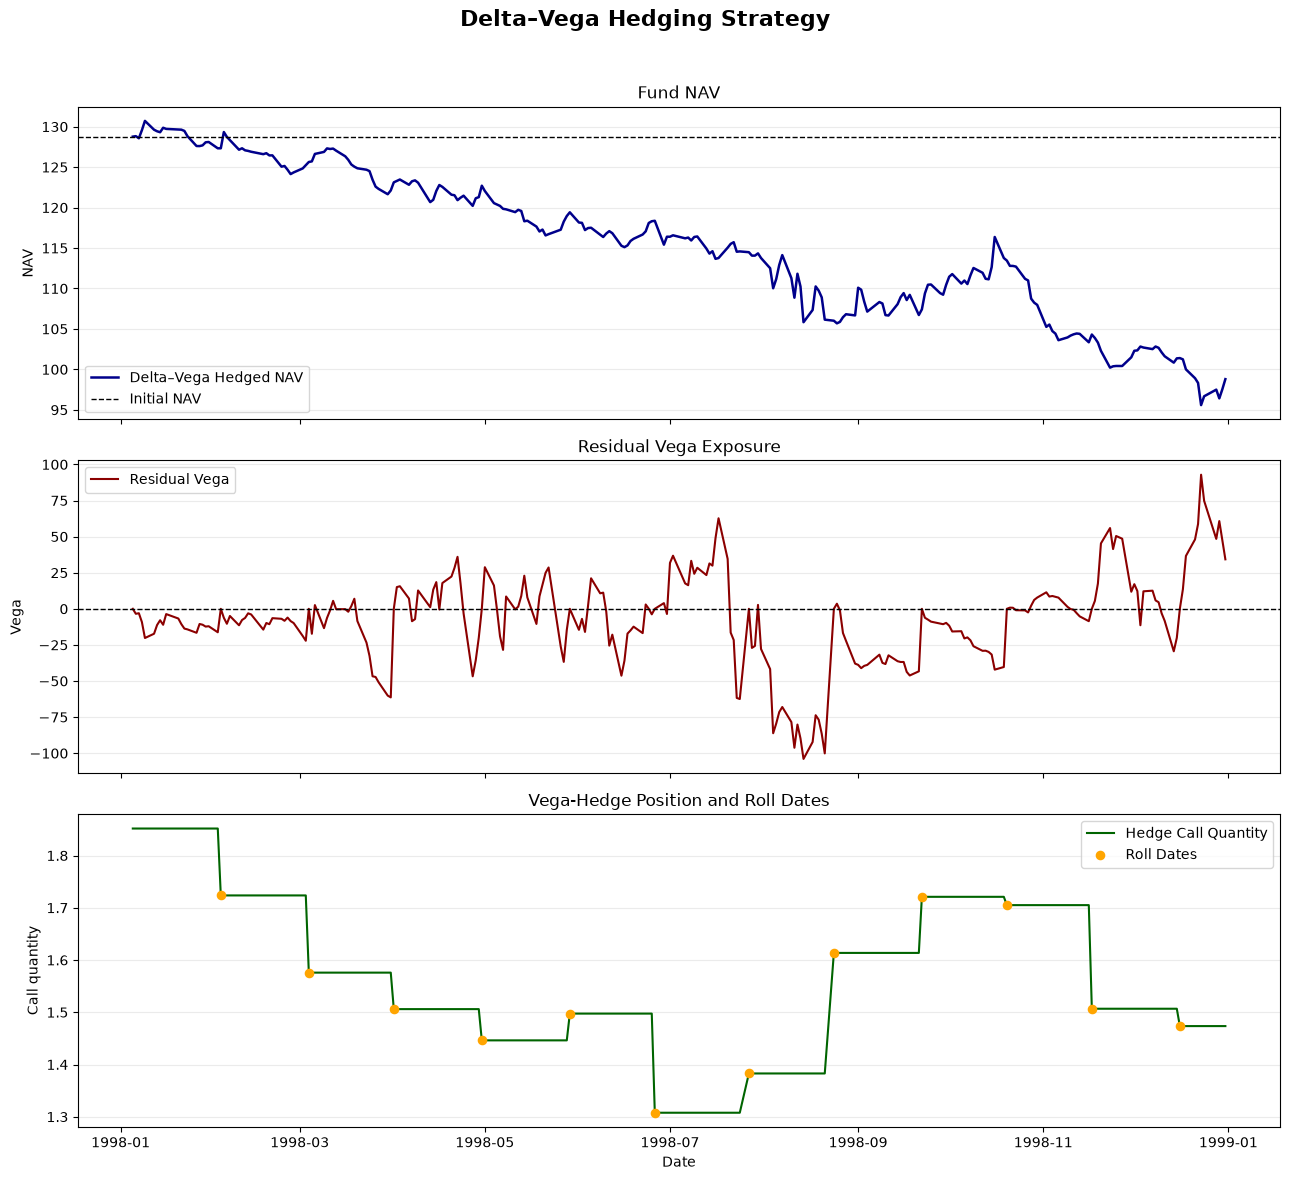

In [37]:
# 5.6 Plot the delta–vega hedging results

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(13, 12),
    sharex=True
)

fig.suptitle(
    "Delta–Vega Hedging Strategy",
    fontsize=16,
    fontweight="bold"
)

axes[0].plot(
    q5_results["date"],
    q5_results["nav"],
    color="darkblue",
    linewidth=1.8,
    label="Delta–Vega Hedged NAV"
)

axes[0].axhline(
    y=q5_results["nav"].iloc[0],
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial NAV"
)

axes[0].set_title("Fund NAV")
axes[0].set_ylabel("NAV")
axes[0].legend(loc="best")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(
    q5_results["date"],
    q5_results["total_vega"],
    color="darkred",
    linewidth=1.5,
    label="Residual Vega"
)

axes[1].axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

axes[1].set_title("Residual Vega Exposure")
axes[1].set_ylabel("Vega")
axes[1].legend(loc="best")
axes[1].grid(axis="y", alpha=0.25)

axes[2].plot(
    q5_results["date"],
    q5_results["hedge_qty_end"],
    color="darkgreen",
    linewidth=1.5,
    label="Hedge Call Quantity"
)

roll_rows = q5_results[q5_results["action"] == "ROLL"]

axes[2].scatter(
    roll_rows["date"],
    roll_rows["hedge_qty_end"],
    color="orange",
    s=35,
    zorder=3,
    label="Roll Dates"
)

axes[2].set_title("Vega-Hedge Position and Roll Dates")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Call quantity")
axes[2].legend(loc="best")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    FIGURES_FOLDER / "delta_vega_hedging_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Strategy Comparison

This section compares the performance of the different hedging strategies developed in the previous sections.

### 6.1 Comparison of the Hedging Strategies

The following chart compares the actual delta hedge with the two counterfactual scenarios and the combined delta–vega hedge. The highlighted area identifies the main phase of the 1998 financial crisis.

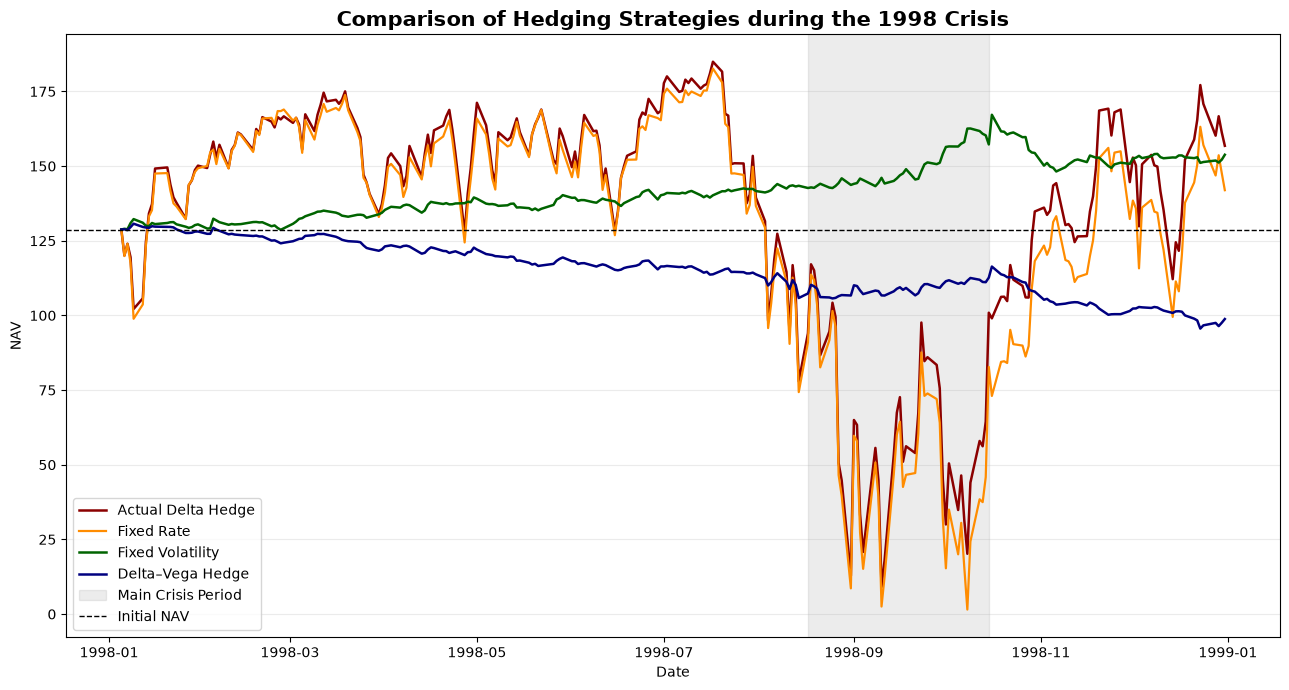

In [38]:
# 6.1 Create the final NAV comparison chart

nav_comparison = pd.DataFrame(
    {
        "date": q3["date"],
        "Actual Delta Hedge": q3["nav"],
        "Fixed Rate": q4_fixed_rate["nav"],
        "Fixed Volatility": q4_fixed_volatility["nav"],
        "Delta–Vega Hedge": q5_results["nav"]
    }
)

FIGURES_FOLDER = Path("figures")
FIGURES_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

fig, ax = plt.subplots(
    figsize=(13, 7)
)

ax.plot(
    nav_comparison["date"],
    nav_comparison["Actual Delta Hedge"],
    color="darkred",
    linewidth=1.8,
    label="Actual Delta Hedge"
)

ax.plot(
    nav_comparison["date"],
    nav_comparison["Fixed Rate"],
    color="darkorange",
    linewidth=1.6,
    label="Fixed Rate"
)

ax.plot(
    nav_comparison["date"],
    nav_comparison["Fixed Volatility"],
    color="darkgreen",
    linewidth=1.8,
    label="Fixed Volatility"
)

ax.plot(
    nav_comparison["date"],
    nav_comparison["Delta–Vega Hedge"],
    color="navy",
    linewidth=1.8,
    label="Delta–Vega Hedge"
)

ax.axvspan(
    pd.Timestamp("1998-08-17"),
    pd.Timestamp("1998-10-15"),
    color="grey",
    alpha=0.15,
    label="Main Crisis Period"
)

ax.axhline(
    y=initial_nav_per_option,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial NAV"
)

ax.set_title(
    "Comparison of Hedging Strategies during the 1998 Crisis",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("NAV")
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_FOLDER / "hedging_strategies_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.2 Performance Summary

The scenarios are evaluated using their initial NAV, crisis-period values, minimum NAV, final NAV, and maximum drawdown.

In [39]:
# 6.2 Define the scenario summary function

def summarize_scenario(name, data):
    minimum_index = data["nav"].idxmin()
    running_maximum = data["nav"].cummax()
    maximum_drawdown = (1 - (data["nav"] / running_maximum).min()) * 100
    september_10_nav = data.loc[data["date"] == pd.Timestamp("1998-09-10"), "nav"].iloc[0]
    september_30_nav = data.loc[data["date"] == pd.Timestamp("1998-09-30"), "nav"].iloc[0]

    return pd.Series(
        {
            "Initial NAV": data["nav"].iloc[0],
            "10 September NAV": september_10_nav,
            "30 September NAV": september_30_nav,
            "Minimum NAV": data.loc[minimum_index, "nav"],
            "Minimum date": data.loc[minimum_index, "date"].strftime("%Y-%m-%d"),
            "Final NAV": data["nav"].iloc[-1],
            "Maximum drawdown (%)": maximum_drawdown
        },
        name=name
    )

In [40]:
# 6.3 Build and display the performance summary

summary_table = pd.DataFrame(
    [
        summarize_scenario("Q3 - Actual delta hedge", q3),
        summarize_scenario("Q4 - Fixed rate", q4_fixed_rate),
        summarize_scenario("Q4 - Fixed volatility", q4_fixed_volatility),
        summarize_scenario("Q5 - Delta-vega hedge", q5_results)
    ]
)

summary_table_display = summary_table.round(
    {
        "Initial NAV": 2,
        "10 September NAV": 2,
        "30 September NAV": 2,
        "Minimum NAV": 2,
        "Final NAV": 2,
        "Maximum drawdown (%)": 2
    }
)

display(summary_table_display)


,Initial NAV,10 September NAV,30 September NAV,Minimum NAV,Minimum date,Final NAV,Maximum drawdown (%)
Q3 - Actual delta hedge,128.770000,9.090000,45.060000,9.090000,1998-09-10,156.790000,95.090000
Q4 - Fixed rate,128.770000,2.520000,31.840000,1.510000,1998-10-08,141.930000,99.170000
Q4 - Fixed volatility,128.770000,146.080000,154.110000,128.670000,1998-02-26,153.800000,11.360000
Q5 - Delta-vega hedge,128.770000,106.710000,110.460000,95.590000,1998-12-23,98.790000,26.870000


### 6.3 Interpretation of the Results

The actual delta-hedging strategy experienced an extreme deterioration during the crisis, with NAV falling from approximately 128.77 to a minimum of 9.09 on 10 September 1998. Although the portfolio subsequently recovered and ended the year above its initial value, the strategy would have faced severe liquidity and funding pressure during the drawdown.

Keeping interest rates fixed does not prevent the collapse in NAV. This indicates that changes in interest rates were not the primary source of the portfolio's losses.

In contrast, the fixed-volatility scenario remains relatively stable throughout the sample. This counterfactual provides strong evidence that the increase in implied volatility was the main driver of the losses suffered by the short-option position.

The delta–vega hedge substantially reduces the crisis-period drawdown because the purchased calls offset much of the client option's vega exposure. However, the strategy ends with a lower NAV because maintaining and rolling the long-option hedge is costly. The comparison therefore illustrates the trade-off between protection against volatility shocks and the long-run cost of insurance.

### 6.4 Model Limitations

The analysis is a stylised reconstruction rather than an exact representation of LTCM's portfolio. The fund's complete positions and transaction history are not publicly observable.

The model assumes Black–Scholes pricing, daily rebalancing, frictionless trading, continuous access to liquidity, and no bid–ask spreads or transaction costs. The VIX is also used as a proxy for the implied volatility of the specific long-dated option.

These assumptions mean that the simulated results should be interpreted as an economic illustration of volatility and hedging risk rather than as an estimate of LTCM's actual daily profit and loss.

In [41]:
# 6.4 Export the final results

OUTPUT_FOLDER = Path("outputs")
OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

summary_table.to_csv(
    OUTPUT_FOLDER / "strategy_summary.csv"
)

nav_comparison.to_csv(
    OUTPUT_FOLDER / "nav_comparison.csv",
    index=False
)

with pd.ExcelWriter(
    OUTPUT_FOLDER / "ltcm_analysis_results.xlsx",
    engine="openpyxl"
) as writer:
    q3.to_excel(writer, sheet_name="Q3 Actual", index=False)
    q4_fixed_rate.to_excel(writer, sheet_name="Q4 Fixed Rate", index=False)
    q4_fixed_volatility.to_excel(writer, sheet_name="Q4 Fixed Volatility", index=False)
    q5_results.to_excel(writer, sheet_name="Q5 Delta Vega", index=False)
    summary_table.to_excel(writer, sheet_name="Summary")
    nav_comparison.to_excel(writer, sheet_name="NAV Comparison", index=False)

print(f"Results exported to: {OUTPUT_FOLDER.as_posix()}")

Results exported to: outputs


## 7. Conclusion

This analysis demonstrates why delta hedging alone can be insufficient for a portfolio containing a large short position in long-dated options. During the 1998 crisis, the sharp increase in implied volatility caused the option liability to rise much faster than the gains generated by the dynamic stock hedge.

The counterfactual analysis identifies volatility, rather than interest-rate movements, as the dominant source of the portfolio's instability. Adding a vega hedge substantially improves crisis resilience and prevents the near-collapse observed under delta hedging alone. Nevertheless, the lower final NAV shows that this protection is not free.

The project therefore highlights a central risk-management trade-off: a strategy may appear profitable over the full investment horizon while still generating an interim drawdown severe enough to create liquidity problems, margin pressure, or forced liquidation.